In [1]:
import yaml
import numpy as np
import polars as pl
import polars.selectors as cs
from tqdm import tqdm
import statsmodels.api as sm
from scipy import stats

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Subset Olink RVAT significant
LOCAL_DATA_DIR = "/home/dnanexus/data_dir/"

# olink_burden_test_file = "proteomics_prs_am_loftee_mac20_burden_regression_results.parquet"
# olink_burden_test_file = "proteomics_prs_loftee_mac20_burden_regression_results.parquet"
olink_burden_test_file = "proteomics_prs_df_loftee_mac20_burden_regression_results.parquet"
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/olink/blacklist/{olink_burden_test_file} -o {LOCAL_DATA_DIR}/{olink_burden_test_file}

olink_whitelist = (
    pl.read_parquet(f'{LOCAL_DATA_DIR}/{olink_burden_test_file}')
    .rename({'gene': 'region'})
    .filter((pl.col('padj')<=0.05) & (pl.col('wilcox_padj')<=0.05) )
    .select(['region'])
    .with_columns(
        phenotype = pl.col('region') + '_olink'
    )
)

olink_correlations_file = "olink_all_mac20_lofteeHC_correlations.parquet"
olink_correlations_file = "olink_LOFTEE_correlations_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/{olink_correlations_file} -o {LOCAL_DATA_DIR}/{olink_correlations_file}

olink_corrs = (
    pl.read_parquet(f'{LOCAL_DATA_DIR}/{olink_correlations_file}')
    .filter(pl.col('correlation')>0)
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .drop_nans()
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

olink_whitelist = (
    olink_whitelist
    .join(olink_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    .sort('loftee_corr_abs', descending=True)
    # .sort('pval_fdr')
    # .unique(subset=["region"], keep="first", maintain_order=True)
)

olink_whitelist

Error: path "/home/dnanexus/data_dir//proteomics_prs_df_loftee_mac20_burden_re
gression_results.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir//olink_LOFTEE_correlations_protrider_t_df
_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet" already exists
but -f/--overwrite was not set


region,phenotype,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64
"""ENSG00000131471""","""ENSG00000131471_olink""",0.16163,0.16163,1.0
"""ENSG00000143382""","""ENSG00000143382_olink""",0.154266,0.154266,1.0
"""ENSG00000099994""","""ENSG00000099994_olink""",0.148376,0.148376,1.0
"""ENSG00000213927""","""ENSG00000213927_olink""",0.147887,0.147887,1.0
"""ENSG00000174080""","""ENSG00000174080_olink""",0.147505,0.147505,1.0
…,…,…,…,…
"""ENSG00000168079""","""ENSG00000168079_olink""",0.002397,0.002397,1.0
"""ENSG00000149564""","""ENSG00000149564_olink""",0.001879,0.001879,1.0
"""ENSG00000141736""","""ENSG00000141736_olink""",0.0014,0.0014,1.0


In [3]:
# Configuration and paths
mac = 20
abs_phenotypes = False

# Maximum number of top-ranked variants per annotation (None = no limit)
max_num_variants = None

# Initialize new annotation variable as None
new_anno_local = None

# Load annotation configuration
if abs_phenotypes:
    config_path = "/home/dnanexus/ukbgym/config_odds.yaml" # If abs_pheno then deleteriousness direction
else:    
    config_path = "/home/dnanexus/ukbgym/config_olink_odds.yaml"

with open(config_path) as f:
    config = yaml.safe_load(f)

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#DD4344""","""LOFTEE HC""",1
"""missense""","""am_pathogenicity""","""#FFD700""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#FFA500""","""ESM1v""",-1
"""missense""","""esm1b_llr""","""#FF6600""","""ESM1b""",-1
"""missense""","""cpt1_llr""","""#E63000""","""CPT-1""",1
…,…,…,…,…
"""regulatory""","""fz_blood_min""","""crimson""","""Flashzoi min across RNA (blood…",-1
"""regulatory""","""fz_all_min""","""#1f77b4""","""Flashzoi min across RNA (all)""",-1
"""regulatory""","""fz_blood_max""","""crimson""","""Flashzoi max across RNA (blood…",1


In [4]:
new_anno_path = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/flashzoi_scores"
# new_anno_filename = "TSS_flashzoi_EURunrelated_variants_burden_test_olink_genes_GENCODEv39_avg_ukbbgym.parquet"
# new_anno_filename = "TSS_flashzoi_EURunrelated_variants_burden_test_olink_genes_GENCODEv39_0_ukbbgym.parquet"
new_anno_filename = "ukbbgym_TSS_promoter_enhancer_TF_variants_all_260218_0_ukbbgym.parquet"
!dx download {new_anno_path}/{new_anno_filename} -o /home/dnanexus/data_dir/

new_anno_local = f'/home/dnanexus/data_dir/{new_anno_filename}'

new_anno_df = (
    pl.scan_parquet(new_anno_local)
    .filter(pl.col('region').is_in(olink_whitelist['region'].unique()))
    .with_columns(
        fz_all_mean = pl.mean_horizontal(cs.starts_with('RNA:').abs()),
        fz_all_min = pl.min_horizontal(cs.starts_with('RNA:')),
        fz_all_max = pl.max_horizontal(cs.starts_with('RNA:')),
    )
    .select(['id', 'region', 'fz_all_min', 'fz_all_max', 'fz_all_mean'])
    .collect()
)

new_anno_df

Error: path "/home/dnanexus/data_dir/ukbbgym_TSS_promoter_enhancer_TF_variants
_all_260218_0_ukbbgym.parquet" already exists but -f/--overwrite was not set


/tmp/ipykernel_657262/920274466.py:18: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,fz_all_min,fz_all_max,fz_all_mean
str,str,f32,f32,f32
"""chr20:44726245:G:A""","""ENSG00000064205""",-0.006898,0.001423,0.000735
"""chr7:8251452:T:C""","""ENSG00000003147""",-0.013746,0.019601,0.00242
"""chr12:10309195:A:G""","""ENSG00000134539""",-0.01001,0.074744,0.016764
"""chr2:162198524:G:A""","""ENSG00000078098""",-0.002404,0.021105,0.005209
"""chr12:132769639:G:C""","""ENSG00000090615""",-0.004555,0.02279,0.001099
…,…,…,…,…
"""chr17:1645491:A:C""","""ENSG00000074660""",-0.033511,0.107099,0.013249
"""chr12:56007826:G:T""","""ENSG00000139531""",-0.021009,0.002934,0.003397
"""chr6:159982939:G:A""","""ENSG00000197081""",-0.008397,0.002198,0.000479


In [5]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"
ANNO_FILE = "annotations_with_all.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

# If True, fillna variants are kept but ranked at the bottom of each annotation
# keep_fillna = True  

# Join new annotation if specified above
if new_anno_local is not None:
    anno = (
        anno
        .join(
            new_anno_df.lazy(),
            on=['id', 'region'],
            how='left'
        )
    )

anno = (
    anno
    .with_columns(
        encode_any_tf = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_tf', 'encode_ca-tf']),
        encode_enhancer = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pels', 'encode_dels']),
        encode_promoter = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pls', 'encode_ca-h3k4me3']),
    )
    .filter(
        # Olink whitelist
        (pl.col('region').is_in(olink_whitelist['region'].unique())),
        
        # Choose Gene Body
        # ((pl.col('consequence_upstream_gene_variant') == False) & (pl.col('consequence_downstream_gene_variant') == False)),
        
        # Choose CDS
        # (pl.col('vep_cds_relaxed')==True),

        # VEP consequences
        # (pl.col('consequence_missense_variant') == True),

        # Choose protein domain
        # (pl.col('ted_domain') == True),
        # (pl.col('ted_domain') == False),
        # (pl.col('mobi_full_lip_priority') == True),
        # (pl.col('mobi_full_disorder_priority') == True),

        # Choose non CDS only
        # UPDATE WITH NEW VEP MANE ANNOS
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)),

        # Choose Introns with/without alternate CDS
        # (pl.col('consequence_intron_variant') == True),

        # Choose regulatory region
        # (pl.col('pangolin_score') < 0.2), # Remove splice variants from the regulatory analysis
        # (pl.col('encode_enhancer') == True),
        # (pl.col('encode_promoter') == True),
        # (pl.col('encode_any_tf') == True),

        # Core promoter
        # (pl.col('promoterai_is_na') == False),

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .with_columns(
        promoterai_abs = pl.col('promoterai').abs(),
        promoterai_under = pl.col('promoterai'),
        promoterai_over = pl.col('promoterai'),
    )
)

# selected_categories = ['missense'] # missense
# selected_categories = ['splicing'] # splicing
# selected_categories = ['regulatory'] # regulatory
selected_categories = ['genetic_diversity', 'conservation'] # genome-wide

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]
selected_annos = list(set(selected_annos).intersection(set(existing_annos)))
fillna_cols = [c+'_is_na' for c in selected_annos]

anno = (
    anno
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

Error: path "/home/dnanexus/data_dir/annotations_with_all.parquet" already
exists but -f/--overwrite was not set


/tmp/ipykernel_657262/4245894806.py:85: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_657262/4245894806.py:94: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


cadd_raw,gpn_score,id,region,verphylop
f32,f32,str,str,f32
0.07539,0.13,"""chr16:12727589:T:C""","""ENSG00000103381""",0.327
0.173018,1.31,"""chr7:146536315:G:A""","""ENSG00000174469""",0.45
0.151091,-1.2,"""chr3:2460852:C:T""","""ENSG00000144619""",-0.166
0.155911,-2.01,"""chr3:186847211:A:T""","""ENSG00000181092""",-0.086
0.110157,-0.58,"""chr4:184181694:G:T""","""ENSG00000164303""",0.384
…,…,…,…,…
0.206284,-1.36,"""chr1:43581785:G:A""","""ENSG00000142949""",0.022
-0.185738,-2.66,"""chr7:130305152:C:A""","""ENSG00000128510""",-0.321
-0.102931,-1.39,"""chr3:196072491:A:G""","""ENSG00000072274""",0.089


In [6]:
anno_fillna = (
    pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")
    .with_columns(
        promoterai_under_is_na = pl.col('promoterai_is_na'),
        promoterai_over_is_na = pl.col('promoterai_is_na'),
    )
)
fillna_cols = set([c+'_is_na' for c in selected_annos]).intersection(set(anno_fillna.collect_schema().names()))

anno_fillna_melted = (
    anno_fillna
    .filter(pl.col('region').is_in(olink_whitelist['region'].unique()))
    .select(['id', 'region'] + list(fillna_cols))
    
    .join(
        anno.select(['id', 'region']).lazy(), 
        on=['id', 'region'], 
        how='semi'
    )
    .unpivot(
        index=["id", "region"],
        on=list(fillna_cols),
        variable_name="annotation",
        value_name="annotation_is_na"
    )
    .filter(
        pl.col('annotation_is_na') == 1
    )
    .with_columns(
        annotation = pl.col('annotation').str.replace('_is_na$', '')
    )
    # .collect(engine='streaming')
)

anno_fillna_melted.head().collect()

/tmp/ipykernel_657262/3954935598.py:35: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_is_na
str,str,str,i8
"""chr2:37129304:C:G""","""ENSG00000055332""","""verphylop""",1
"""chr4:17459787:T:C""","""ENSG00000151552""","""verphylop""",1
"""chr13:101671728:G:A""","""ENSG00000198542""","""verphylop""",1
"""chr2:165812954:A:G""","""ENSG00000115339""","""verphylop""",1
"""chr5:78868999:C:T""","""ENSG00000113273""","""verphylop""",1


In [7]:
melted_anno = (
    anno.lazy()

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]).lazy(),
        on="annotation",
        how="left"
    )
    .filter(pl.col('category').is_in(selected_categories))
    .unique()

    # Remove null annotation scores
    .drop_nulls('annotation_score')

    # Remove variants for each annotation which are not scored
    .join(
        anno_fillna_melted,
        on=['id', 'region', 'annotation'],
        how='anti'
    )

    # Correct scores by annotation direction
    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir").cast(pl.Float32)
    )
    
    # Implement filtering based on the defined percentile
    .with_columns(
        # annotation_score_dircor_rank_desc = pl.col('annotation_score_dircor').rank(method="ordinal", descending=True).over(["annotation"]).cast(pl.Float32)
        annotation_score_dircor_rank_desc = pl.col('annotation_score_dircor').rank(method="max", descending=True).over(["annotation"]).cast(pl.Float32)
    )
    .drop(['annotation_score_dircor'])

    .collect(engine='streaming')
)

melted_anno

/tmp/ipykernel_657262/3977662353.py:46: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor_rank_desc
str,str,str,f32,str,i8,f32
"""chr2:208350561:T:C""","""ENSG00000115020""","""verphylop""",2.223,"""conservation""",1,593779.0
"""chr3:28242489:A:T""","""ENSG00000187118""","""verphylop""",-0.656,"""conservation""",1,1.6110107e7
"""chr12:40780059:C:T""","""ENSG00000018236""","""verphylop""",-0.734,"""conservation""",1,1.6538679e7
"""chr19:4865777:G:C""","""ENSG00000105355""","""verphylop""",-0.559,"""conservation""",1,1.5549399e7
"""chr10:51347523:C:T""","""ENSG00000185532""","""verphylop""",-0.314,"""conservation""",1,1.3804081e7
…,…,…,…,…,…,…
"""chr17:73505402:C:T""","""ENSG00000069188""","""verphylop""",-0.1,"""conservation""",1,1.1727939e7
"""chr17:82316713:G:A""","""ENSG00000173762""","""verphylop""",-0.34,"""conservation""",1,1.4015768e7
"""chr7:108182726:T:C""","""ENSG00000091129""","""verphylop""",0.2,"""conservation""",1,7.648777e6


In [8]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus"

# APPV_FILE = "cauc_protrider_lite_prs_t_df_all_genes_EURunrelated_appv_percentiles.parquet"
# APPV_FILE = "olink_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"
APPV_FILE = "olink_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
olink_appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Merge phenotype data and annotation data
olink_appv = (
    olink_appv
    .filter(
        (pl.col('n_individuals') <= mac)
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)

Error: path "/home/dnanexus/olink_protrider_t_df_loftee_mac20_EURunrelated_app
v_percentiles_small_desc.parquet" already exists but -f/--overwrite was not
set


In [9]:
olink_appv.head().collect()

id,phenotype,mean_pheno_value,n_individuals
str,str,f32,i32
"""chr12:24805471:G:A""","""ENSG00000060982_olink""",0.328067,1
"""chr12:122768837:C:G""","""ENSG00000139726_olink""",-1.312343,1
"""chr2:102332039:T:C""","""ENSG00000115604_olink""",0.249114,1
"""chr2:37346399:G:A""","""ENSG00000115828_olink""",1.00197,1
"""chr16:89195863:C:G""","""ENSG00000129910_olink""",-0.059154,1


## Average z-score by annotation rank (sliding window)

In [10]:
# Sliding window parameters
window_size = 1_000  # Number of variants in the sliding window
step_size = 1_0      # Step between sampled points (controls plot smoothness)
max_num_variants = 1_000_000

In [11]:
# --- Join variant z-scores with annotation ranks, then apply sliding window ---

id_region = anno.select(['id', 'region']).unique().lazy()

# Get variant-level z-scores joined with olink whitelist
variant_zscores = (
    olink_appv
    .join(id_region, on='id', how='inner')
    .join(olink_whitelist.lazy(), on=['region', 'phenotype'], how='inner')
    .select(['id', 'region', 'mean_pheno_value'])
    .collect(engine='streaming')
)

print(f"Variant z-scores: {variant_zscores.shape[0]} variant-gene pairs")

# Sliding window over row position (not rank values) to guarantee window_size variants per window.
# Sorted by rank within annotation, row_pos = sequential index = "Top N variants".
# rolling_mean/std with min_samples=window_size ensures only full windows are kept.
# Using trailing window (center=False) so each bin is identified by its last rank.
zscore_binned = (
    variant_zscores.lazy()
    .join(
        melted_anno.lazy().select(['id', 'region', 'annotation', 'annotation_score_dircor_rank_desc']),
        on=['id', 'region'],
        how='inner'
    )
    .sort(['annotation', 'annotation_score_dircor_rank_desc'])
    .with_columns(
        row_pos = pl.col('annotation').cum_count().over('annotation'),
    )
    # Limit to top max_num_variants per annotation if set
    .pipe(lambda df: df.filter(pl.col('row_pos') <= max_num_variants) if max_num_variants is not None else df)
    .with_columns(
        mean_zscore = pl.col('mean_pheno_value')
            .rolling_mean(window_size=window_size, min_samples=window_size, center=False)
            .over('annotation'),
        sd_zscore = pl.col('mean_pheno_value')
            .rolling_std(window_size=window_size, min_samples=window_size, center=False)
            .over('annotation'),
    )
    # Sample every step_size positions
    .filter(
        (pl.col('row_pos') % step_size == 0)
    )
    .drop_nulls('mean_zscore')
    .with_columns(
        bin_end = pl.col('row_pos').cast(pl.Float64),
        se_zscore = pl.col('sd_zscore') / (window_size ** 0.5),
    )
    .with_columns(
        ci_lower = pl.col('mean_zscore') - 1.96 * pl.col('se_zscore'),
        ci_upper = pl.col('mean_zscore') + 1.96 * pl.col('se_zscore'),
    )
    .select(['annotation', 'bin_end', 'mean_zscore', 'sd_zscore', 'se_zscore', 'ci_lower', 'ci_upper'])
    .sort(['annotation', 'bin_end'])
    .collect()
)

print(f"Sliding window results: {zscore_binned.shape[0]} points across {zscore_binned['annotation'].n_unique()} annotations")
zscore_binned

Variant z-scores: 4445925 variant-gene pairs
Sliding window results: 299703 points across 3 annotations


annotation,bin_end,mean_zscore,sd_zscore,se_zscore,ci_lower,ci_upper
str,f64,f32,f32,f32,f32,f32
"""cadd_raw""",1000.0,-1.794675,1.597444,0.050516,-1.893685,-1.695664
"""cadd_raw""",1010.0,-1.812817,1.596841,0.050497,-1.911791,-1.713844
"""cadd_raw""",1020.0,-1.837436,1.589566,0.050267,-1.935958,-1.738913
"""cadd_raw""",1030.0,-1.853065,1.592348,0.050354,-1.95176,-1.754371
"""cadd_raw""",1040.0,-1.872156,1.586233,0.050161,-1.970472,-1.773841
…,…,…,…,…,…,…
"""verphylop""",999960.0,0.02522,0.951971,0.030104,-0.033783,0.084224
"""verphylop""",999970.0,0.025794,0.948554,0.029996,-0.032998,0.084586
"""verphylop""",999980.0,0.020075,0.947347,0.029958,-0.038642,0.078792


## Plotting

In [12]:
plt_df = (
    zscore_binned
    .drop_nans()
    .with_columns(
        log_bin_end = pl.col('bin_end').log10(),
        log_bin_end_inv = (1 / pl.col('bin_end')).log10(),
    )
    .join(
        anno_config_df.filter(pl.col('category').is_in(selected_categories)).select(['annotation', 'color', 'label', 'category']).unique(),
        on='annotation',
        how='left'
    )
    .filter(pl.col('category').is_in(selected_categories))
    .sort('bin_end')
)

plt_df

annotation,bin_end,mean_zscore,sd_zscore,se_zscore,ci_lower,ci_upper,log_bin_end,log_bin_end_inv,color,label,category
str,f64,f32,f32,f32,f32,f32,f64,f64,str,str,str
"""cadd_raw""",1000.0,-1.794675,1.597444,0.050516,-1.893685,-1.695664,3.0,-3.0,"""chocolate""","""CADD Raw""","""genetic_diversity"""
"""gpn_score""",1000.0,-1.040824,1.61168,0.050966,-1.140717,-0.940931,3.0,-3.0,"""pink""","""GPN-MSA""","""conservation"""
"""verphylop""",1000.0,-0.769091,1.500877,0.047462,-0.862116,-0.676066,3.0,-3.0,"""#483D8B""","""Vertebrate PhyloP""","""conservation"""
"""cadd_raw""",1010.0,-1.812817,1.596841,0.050497,-1.911791,-1.713844,3.004321,-3.004321,"""chocolate""","""CADD Raw""","""genetic_diversity"""
"""gpn_score""",1010.0,-1.037207,1.608048,0.050851,-1.136874,-0.937539,3.004321,-3.004321,"""pink""","""GPN-MSA""","""conservation"""
…,…,…,…,…,…,…,…,…,…,…,…
"""gpn_score""",999990.0,-0.033791,0.945817,0.029909,-0.092413,0.024831,5.999996,-5.999996,"""pink""","""GPN-MSA""","""conservation"""
"""verphylop""",999990.0,0.023252,0.950449,0.030056,-0.035658,0.082161,5.999996,-5.999996,"""#483D8B""","""Vertebrate PhyloP""","""conservation"""
"""cadd_raw""",1e6,-0.03691,0.897768,0.02839,-0.092554,0.018734,6.0,-6.0,"""chocolate""","""CADD Raw""","""genetic_diversity"""


In [13]:
# LOFTEE point
loftee_vars = (
    pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")
    .filter(pl.col('region').is_in(olink_whitelist['region'].unique()))
    .filter(pl.col('loftee_hc')==1)
    .collect(engine='streaming')
)

id_region = loftee_vars.select(['id', 'region']).unique().lazy()

# Get variant-level z-scores joined with olink whitelist
loftee_zscores = (
    pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")
    .join(id_region, on='id', how='inner')
    .join(olink_whitelist.lazy(), on=['region', 'phenotype'], how='inner')
    .select(['id', 'region', 'mean_pheno_value'])
    .collect(engine='streaming')
)

mean_zscore = loftee_zscores['mean_pheno_value'].mean()
se_zscore = loftee_zscores['mean_pheno_value'].std() / (loftee_zscores.shape[0] ** 0.5)
ci_se_lower = mean_zscore - 1.96 * se_zscore
ci_se_upper = mean_zscore + 1.96 * se_zscore

loftee_point_df = pl.DataFrame({
    'label': 'LOFTEE HC',
    'n_vars': loftee_zscores.shape[0],
    'log_bin_end': np.log10(loftee_zscores.shape[0]),
    'log_bin_end_inv': np.log10(1 / loftee_zscores.shape[0]),
    'mean_zscore': mean_zscore,
    'se_zscore': se_zscore,
    'ci_se_lower': ci_se_lower,
    'ci_se_upper': ci_se_upper
})

loftee_point = [
    geom_point(loftee_point_df, aes(x='log_bin_end', y='mean_zscore'), size=1),
    geom_errorbar(loftee_point_df, aes(x='log_bin_end', ymin='ci_se_lower', ymax='ci_se_upper'), width=0.01),
    geom_text(loftee_point_df, aes(x='log_bin_end', y='mean_zscore', label='label'), nudge_y=0.1, size=12, ha='right'),
]

/tmp/ipykernel_657262/2624153728.py:6: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


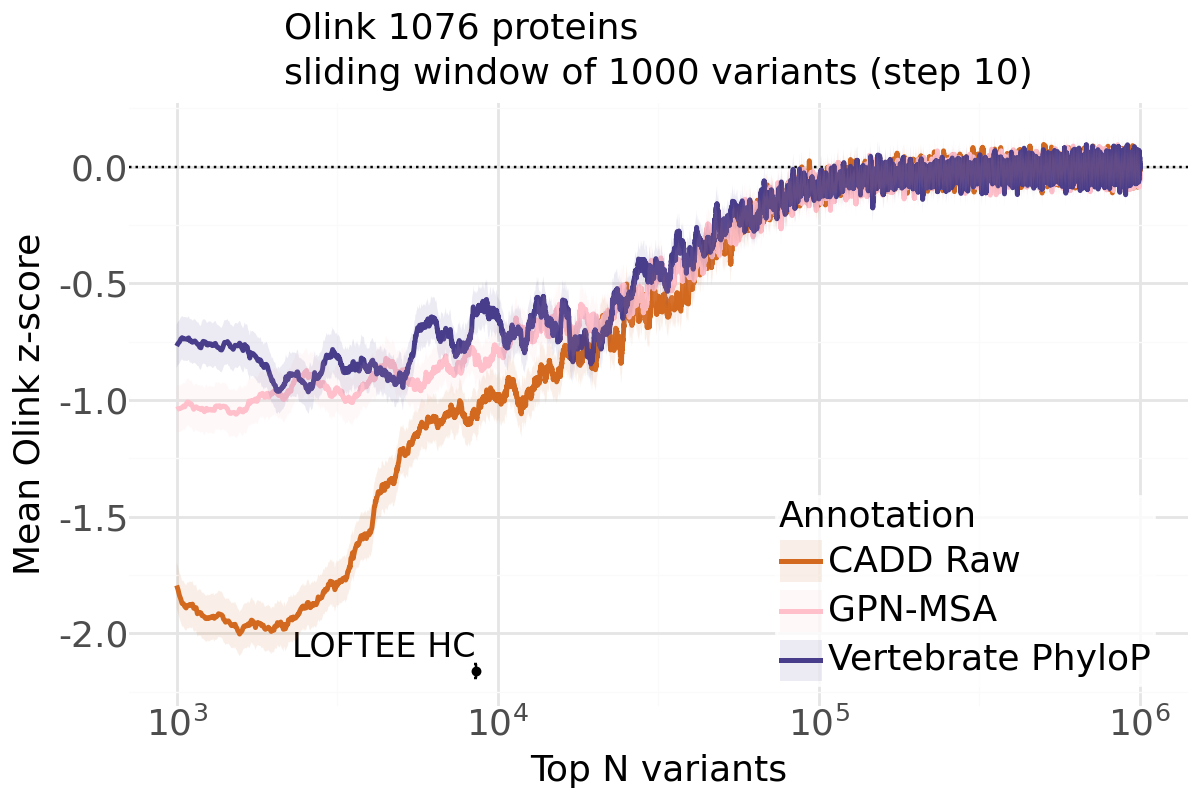

In [14]:
# x_label_ext = "Top N missense variants"
# x_label_ext = "Top N structured domain (missense) variants"
# x_label_ext = "Top N non-structured domain (missense) variants"
# x_label_ext = "Top N LIP domain (missense) variants"
# x_label_ext = "Top N intronic variants"
# x_label_ext = "Top N enhancer (pELS & dELS) variants"
# x_label_ext = "Top N promoter (PLS & CA-H3K4me3) variants"
# x_label_ext = "Top N TF binding region (TC & CA-TF) variants"
x_label_ext = "Top N variants"

plot_df = (
    plt_df
    .filter(
        # (pl.col('annotation').is_in(['promoterai', 'fz_all_min']))
        # (pl.col('annotation').is_in(['promoterai', 'fz_all_max']))
        # (pl.col('annotation').is_in(['am_pathogenicity', 'esmscoremissense']))
    )
)

# Generate breaks and labels for x-axis
max_rank = zscore_binned['bin_end'].max()
min_rank = zscore_binned['bin_end'].min()
start_exp = int(np.floor(np.log10(min_rank)))
end_exp = int(np.ceil(np.log10(max_rank)))
breaks_linear = np.arange(start_exp, end_exp + 1)
labels_sci = [f"$10^{{{int(b)}}}$" for b in breaks_linear]

color_dict = dict(zip(plt_df['label'], plt_df['color']))

(
    ggplot(
        plot_df,
        # aes(x='bin_id', y='mean_zscore')
        aes(x='log_bin_end', y='mean_zscore')
    )
    + loftee_point
    + geom_hline(aes(yintercept=0), color='black', linetype='dotted')
    + geom_line(aes(color='label'), size=1)
    + geom_ribbon(aes(ymin='ci_lower', ymax='ci_upper', fill='label'), alpha=0.1)
    + scale_fill_manual(values=color_dict)
    + scale_color_manual(values=color_dict)
    + labs(
        title=f"Olink {olink_whitelist.shape[0]} proteins\nsliding window of {window_size} variants (step {step_size})",
        y="Mean Olink z-score",
        x=x_label_ext,
        color="Annotation",
        fill="Annotation",
    )
    + scale_x_continuous(
        breaks=breaks_linear,
        labels=labels_sci
    )
    + theme_minimal()
    + theme(
        figure_size=(6, 4),
        title=element_text(size=13, lineheight=1.4),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13, lineheight=1.4),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        legend_position=(0.95, 0.05),
        legend_background=element_rect(fill="white", color='white', alpha=0.8),
        plot_background=element_rect(fill="white", color="white"),
    )
)

## Extended plot (linear scale + point plot)

In [15]:
# Include LOFTEE HC reference point in the point plot
show_loftee_point = False

# X-axis variable for plots:
# x_col = 'log_bin_end_inv' #log scale, top variants on the right
x_col = 'bin_end'

# Show compact point plot panel next to the line plot
show_point_plot = True

# Maximum bin_end for the linear scale plot
max_bin_end = 10_000

# Update LOFTEE point with bin_end and ci_lower/ci_upper columns
loftee_point_ext = pl.DataFrame({
    'label': 'LOFTEE HC',
    'n_vars': loftee_zscores.shape[0],
    'bin_end': float(loftee_zscores.shape[0]),
    'log_bin_end_inv': np.log10(1 / loftee_zscores.shape[0]),
    'mean_zscore': mean_zscore,
    'se_zscore': se_zscore,
    'ci_lower': mean_zscore - 1.96 * se_zscore,
    'ci_upper': mean_zscore + 1.96 * se_zscore,
})

In [16]:
plot_df_ext = (
    plt_df
    .filter(
        (pl.col('bin_end') <= max_bin_end),
        # (~pl.col('annotation').is_in(['esm1b_llr', 'esmscoremissense']))
        (pl.col('annotation').is_in(['promoterai_under', 'fz_all_min']))
    )
)

color_dict = dict(zip(plt_df['label'], plt_df['color']))

def apply_theme_minimal(ax):
    """Apply plotnine theme_minimal style to a matplotlib axis."""
    ax.set_facecolor('white')
    ax.grid(True, which='major', color='#d3d3d3', linewidth=0.5)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(length=0)

# --- Figure setup: point plot on left, line plot on right ---
if show_point_plot:
    fig, (ax_point, ax_line) = plt.subplots(
        1, 2, figsize=(8.5, 4), sharey=True,
        gridspec_kw={'width_ratios': [1, 5], 'wspace': 0.05}
    )
else:
    fig, ax_line = plt.subplots(figsize=(6, 4))
    ax_point = None

apply_theme_minimal(ax_line)
if ax_point is not None:
    apply_theme_minimal(ax_point)

# --- Line plot (right panel) ---
for label in sorted(plot_df_ext['label'].unique().to_list()):
    sub = plot_df_ext.filter(pl.col('label') == label)
    c = color_dict[label]
    x = sub[x_col].to_numpy()
    ax_line.plot(x, sub['mean_zscore'].to_numpy(), color=c, linewidth=1, label=label)
    ax_line.fill_between(x, sub['ci_lower'].to_numpy(), sub['ci_upper'].to_numpy(), color=c, alpha=0.1)

ax_line.set_xlabel(x_label_ext, fontsize=13)
ax_line.set_title(
    f"Olink {olink_whitelist.shape[0]} proteins\n"
    f"sliding window of {window_size} variants (step {step_size})",
    fontsize=13)
ax_line.legend(loc='lower right', fontsize=11, framealpha=0.8, edgecolor='white')
ax_line.tick_params(labelsize=13)

if x_col == 'log_bin_end_inv':
    max_rank = zscore_binned['bin_end'].max()
    min_rank = zscore_binned['bin_end'].min()
    start_exp = int(np.floor(np.log10(1/max_rank)))
    end_exp = int(np.ceil(np.log10(1/min_rank)))
    breaks = np.arange(start_exp, end_exp + 1)
    ax_line.set_xticks(breaks)
    ax_line.set_xticklabels([f"$10^{{{int(-b)}}}$" for b in breaks])

# --- Y-axis label on the leftmost panel ---
if ax_point is not None:
    ax_point.set_ylabel("Mean Olink z-score", fontsize=13)
    ax_line.tick_params(labelleft=False)
else:
    ax_line.set_ylabel("Mean Olink z-score", fontsize=13)

# --- Point plot (left panel) ---
if ax_point is not None:
    first_bin = plot_df_ext.filter(pl.col('bin_end') == float(window_size))

    compact_df = first_bin.select([
        'label',
        pl.col('mean_zscore').cast(pl.Float64),
        pl.col('ci_lower').cast(pl.Float64),
        pl.col('ci_upper').cast(pl.Float64),
        'color',
    ])

    if show_loftee_point:
        loftee_row = pl.DataFrame({
            'label': ['LOFTEE HC'],
            'mean_zscore': [float(loftee_point_ext['mean_zscore'][0])],
            'ci_lower': [float(loftee_point_ext['ci_lower'][0])],
            'ci_upper': [float(loftee_point_ext['ci_upper'][0])],
            'color': ['black'],
        })
        compact_df = pl.concat([compact_df, loftee_row])

    compact_df = compact_df.sort('mean_zscore', descending=True)

    for i, row in enumerate(compact_df.iter_rows(named=True)):
        ax_point.errorbar(
            i, row['mean_zscore'],
            yerr=[[row['mean_zscore'] - row['ci_lower']],
                  [row['ci_upper'] - row['mean_zscore']]],
            fmt='o', color=row['color'], capsize=3, markersize=6,
        )

    # ax_point.axhline(0, linestyle=':', color='grey', linewidth=0.8)
    ax_point.set_xticks([])
    ax_point.set_xlabel("")
    ax_point.set_title(f"Top {window_size}", fontsize=13)
    ax_point.tick_params(labelsize=13)

# --- Compute tight y-limits from all plotted data ---
all_y_vals = []
for label in plot_df_ext['label'].unique().to_list():
    sub = plot_df_ext.filter(pl.col('label') == label)
    all_y_vals.extend(sub['ci_lower'].to_list())
    all_y_vals.extend(sub['ci_upper'].to_list())
if ax_point is not None and 'compact_df' in dir():
    all_y_vals.extend(compact_df['ci_lower'].to_list())
    all_y_vals.extend(compact_df['ci_upper'].to_list())
y_min, y_max = min(all_y_vals), max(all_y_vals)
y_pad = (y_max - y_min) * 0.05
ax_line.set_ylim(y_min - y_pad, y_max + y_pad)

fig.patch.set_facecolor('white')
fig.tight_layout()
fig.subplots_adjust(wspace=0.05)
plt.show()
plt.close(fig)

/tmp/ipykernel_657262/2850531244.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ValueError: min() arg is an empty sequence